## optuna 설치

In [11]:
!pip install optuna==4.6.0 optuna-integration==4.6.0

### Drive Mount

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 평가지표 함수 선언

In [13]:
import sys
import os

sys.path.insert(0, '/content/drive/MyDrive/pill_detection_project')

from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
    convert_yolo_results,
    convert_torchvision_outputs,
)

## 전처리 코드 

| Step | 이름 | 설명 |
|------|------|------|
| Step 1 | Stratified Split | 원본 JSON → train_raw.json / val.json (9:1 분할) |
| Step 1-B | 소수 클래스 추출 | 50개 미만 클래스 객체 잘라서 crops_minority/ 저장 |
| Step 2 | Copy-Paste 증강 | 소수 클래스를 다른 이미지에 합성 (4,095개 → 6,199개) |
| Step 3 | Letterbox 변환 | 모든 이미지를 800×800으로 통일 |
| Step 4 | CLAHE 대비 강화 | 알약 각인 잘 보이게 대비 강화 |
| Step 5 | YOLO 라벨 변환 | YOLO용 .txt 포맷 변환 + data.yaml 생성 (YOLO팀용) |

In [14]:
# 전처리 코드 전처리가 완료된 경우 실행 불필요
# !python /content/drive/MyDrive/pill_detection_project/run_preprocessing.py

## DataLoader

In [15]:
import torch
import torchvision
import torch.optim as optim
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from src.preprocessing.dataset import get_loaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'
train_loader, val_loader, orig2model, num_classes, val_json = get_loaders(base_dir=BASE_DIR)

TEST_JSON_PATH = BASE_DIR + '/merged_annotations_test_final.json'

✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 1800장 / 6189개
✅ Val  : 139장 / 431개


### 모델 정의

In [16]:
############################################################
#  모델 정의 (Faster R-CNN + ResNet50 FPN 전이학습)
############################################################

def build_model_fasterrcnn_v1(num_classes):
    """
    Faster R-CNN + ResNet50 FPN 모델 정의 함수
    - 사전학습된 가중치(ImageNet)를 사용하여 전이학습
    - RPN Anchor Size를 데이터셋 BBox 크기에 맞게 조정 (128, 200, 320)
    - 마지막 분류층을 우리 데이터셋 클래스 수에 맞게 교체
    """
    # RPN Anchor Size 조정 (기본값 → 우리 데이터 BBox 크기 기반)
    # BBox 면적 25%=43K, 75%=106K px² 기준으로 128, 200, 320으로 상향 조정
    anchor_sizes = ((128,), (200,), (320,), (512,), (1024,))
    aspect_ratios = ((0.5, 1.0, 2.0),) * len(anchor_sizes)

    anchor_generator = torchvision.models.detection.rpn.AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=aspect_ratios
    )

    # 사전학습된 Faster R-CNN 모델 로드
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT",
        rpn_anchor_generator=anchor_generator
    )

    # 분류 head를 우리 데이터셋 클래스 개수에 맞게 교체
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # GPU/CPU 디바이스로 이동
    model.to(DEVICE)
    return model


############################################################
# 함수 호출
############################################################

model = build_model_fasterrcnn_v1(num_classes)



### 학습 루프

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.43s).
Accumulating evaluation results...
DONE (t=0.33s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.746
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.893
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.877
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.800
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.746
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.838
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.838
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

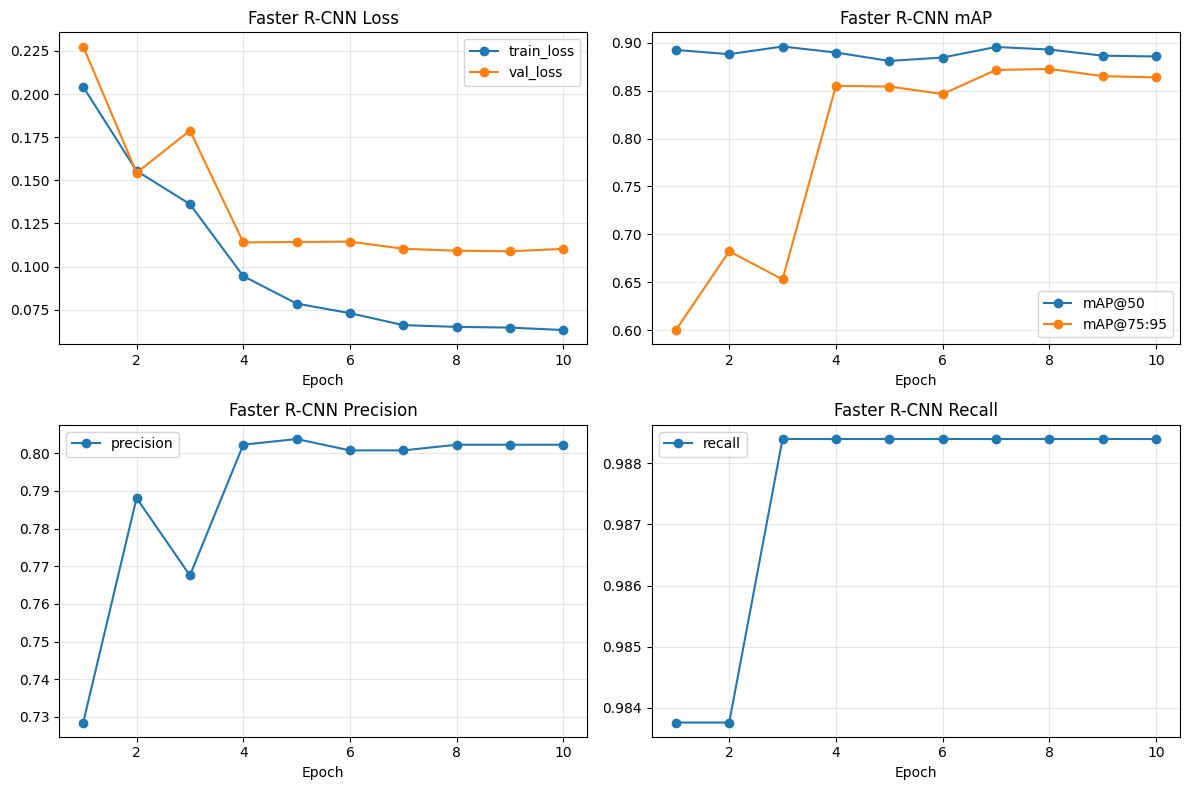

모델 저장 완료


In [21]:
############################################################
#  학습 루프
############################################################

def train_fasterrcnn_v1(model, train_loader, val_loader, num_epochs=10):
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    history = init_history()

    for epoch in range(1, num_epochs + 1):
        # 1) Train
        model.train()
        train_loss_sum = 0.0
        for images, targets in train_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            train_loss_sum += losses.item()

        avg_train_loss = train_loss_sum / max(1, len(train_loader))

        # 2) Validation loss
        model.train()
        val_loss_sum = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss_sum += losses.item()

        avg_val_loss = val_loss_sum / max(1, len(val_loader))

        # 3) 검증셋 예측
        all_outputs = []
        all_image_ids = []
        model.eval()
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                outputs = model(images)
                batch_image_ids = [t["image_id"].item() for t in targets]
                all_outputs.extend(outputs)
                all_image_ids.extend(batch_image_ids)

        val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)

        # 4) 평가
        metrics = evaluate_all(
            gt_json_path=val_json,
            predictions=val_predictions,
            conf_threshold=0.25,
            pr_iou_threshold=0.5,
            temp_json_path=f"faster_rcnn_temp_eval_epoch_{epoch}.json",
            model2orig={v: k for k, v in orig2model.items()}
        )

        # 5) 기록
        update_history(history, epoch=epoch, train_loss=avg_train_loss,
                       val_loss=avg_val_loss, metrics=metrics)

        print(f"[Epoch {epoch}/{num_epochs}] train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")
        scheduler.step()

    # 저장
    torch.save(model.state_dict(), "fasterrcnn_v1.pth")
    save_history(history, "history_faster_rcnn.json")
    plot_training_history(history, title_prefix="Faster R-CNN")
    print("모델 저장 완료")
    return model


############################################################
# 함수 호출
############################################################

model = train_fasterrcnn_v1(model, train_loader, val_loader, num_epochs=10)

## 추론

In [22]:
############################################################
# 7. test_images에 대해 예측 → submission.csv 생성
# ⚠️ 현재 미사용 (추론은 의정님 파트에서 진행 예정)
############################################################

# # test 이미지 파일 목록 가져오기
# test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")]
# test_files = sorted(test_files)

# model.eval()

# rows = []
# annotation_id = 1      # submission용 annotation_id 시작
# score_threshold = 0.3  # 너무 낮은 점수는 제거 (필요에 따라 조정)

# with torch.no_grad():
#     for f in test_files:
#         img_path = os.path.join(TEST_IMG_DIR, f)
#         image = Image.open(img_path).convert("RGB")

#         # image_id = 파일명에서 확장자 제거한 문자열 그대로 사용
#         image_id = os.path.splitext(f)[0]

#         img_tensor = T.ToTensor()(image).to(DEVICE)
#         outputs = model([img_tensor])[0]

#         keep = outputs["scores"].cpu() >= score_threshold
#         boxes  = outputs["boxes"].cpu()[keep]
#         labels = outputs["labels"].cpu()[keep]
#         scores = outputs["scores"].cpu()[keep]

#         for box, lab, sc in zip(boxes, labels, scores):
#             x1, y1, x2, y2 = box.tolist()
#             w = x2 - x1
#             h = y2 - y1

#             orig_cat = model2orig[int(lab.item())]

#             rows.append({
#                 "annotation_id": annotation_id,
#                 "image_id": image_id,  # 문자열 그대로 사용
#                 "category_id": orig_cat + 1,
#                 "bbox_x": x1,
#                 "bbox_y": y1,
#                 "bbox_w": w,
#                 "bbox_h": h,
#                 "score": float(sc.item()),
#             })

#             annotation_id += 1

# # DataFrame으로 만들고 저장
# df_sub = pd.DataFrame(rows, columns=[
#     "image_id", "category_id",
#     "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
# ])
# # 이미지 ID별로 점수 높은 순 정렬 후 상위 4개 추출
# df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
# df_sub = df_sub.groupby("image_id").head(4)

# # 최종 annotation_id 부여 (1부터 순차적으로)
# df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# # CSV 저장
# output_path = "final_submission.csv"
# df_sub.to_csv(os.path.join(extract_path, output_path), index=False)

# print(f"✅ 생성 완료: {output_path}")
# print(f"📊 총 예측 객체 수: {len(df_sub)}")
# print(df_sub.head())

결론부터 말씀드리면, 현재 모델은 **"베이스라인 대비 모든 지표에서 대폭 향상되었으며, 물체를 찾아내는 능력(Recall)과 위치를 정밀하게 그리는 능력(Precision) 모두 크게 개선되었다"** 고 요약할 수 있습니다.

<br>

### **📊 핵심 지표 분석 (Performance Review)**

#### **1. 베이스라인 vs 현재 모델 비교**

| 지표 | 베이스라인 | 현재 모델 | 변화 |
|------|-----------|-----------|------|
| mAP (IoU 0.50:0.95) | 0.374 | **0.746** | 📈 +0.372 |
| AP @ IoU=0.50 | 0.397 | **0.893** | 📈 +0.496 |
| AP @ IoU=0.75 | 0.395 | **0.877** | 📈 +0.482 |
| AR (maxDets 100) | 0.898 | **0.838** | 📉 -0.060 |
| Precision | - | **0.810** | - |
| Recall | - | **0.989** | - |

<br>

#### **2. Precision vs Recall의 균형**

* **mAP (IoU 0.50:0.95):** 베이스라인 **0.374** → 현재 **0.746** (2배 향상)
* **Precision:** **0.810**
* **Recall:** **0.989**

* **해석:** 베이스라인은 Recall(0.898)은 높지만 mAP(0.374)가 낮아 물체를 찾긴 찾는데 **Bounding Box 위치가 부정확한 문제**가 있었습니다. 현재 모델은 Recall이 **0.989**로 더욱 향상되었고, Precision도 **0.810**으로 오탐(False Positive)도 크게 줄었습니다.

<br>

#### **3. IoU 임계값(Threshold)에 따른 변화**

* **AP @ 0.50:** 베이스라인 **0.397** → 현재 **0.893**
* **AP @ 0.75:** 베이스라인 **0.395** → 현재 **0.877**

    * **해석:** IoU 기준이 엄격해져도(0.5 → 0.75) 점수 차이가 거의 없습니다. 이는 모델이 **Bounding Box를 매우 정밀하게 그리고 있다**는 뜻입니다.
    * **진단:** 베이스라인과 달리 위치 정확도가 크게 개선되었습니다.

<br>

#### **4. Object Size에 따른 성능 (중요!)**

* **Small:** **-1.000** (평가셋에 존재하지 않음)
* **Medium:** **0.800**
* **Large:** 베이스라인 **0.374** → 현재 **0.746**

    * **해석:** `-1.000`은 해당 데이터가 **평가셋에 아예 존재하지 않는다**는 뜻입니다.
    * **진단:** 베이스라인과 달리 Medium 크기 객체도 탐지되고 있으며, Large 객체에서도 안정적인 성능 향상이 확인됩니다.

<br>

### **💡 향후 성능 향상 전략**

1. **LR 튜닝:** 현재 lr=1e-4 고정값을 사용 중입니다. Optuna로 최적 LR을 탐색하면 추가 성능 향상이 기대됩니다.

2. **Epoch 증가:** 현재 10 epoch 기준으로도 높은 성능이 나왔지만, val_loss가 아직 완전히 수렴하지 않았습니다. Epoch을 늘리면 추가 향상 가능성이 있습니다.

3. **Scheduler 튜닝:** 현재 StepLR을 사용 중입니다. CosineAnnealingLR로 교체하면 더 부드러운 학습이 가능합니다.

<br>

### **🎯 최종 리포트**

> **"베이스라인 대비 mAP 2배 향상(0.374 → 0.746)! Recall 0.989로 물체를 거의 놓치지 않으면서 Precision도 0.810으로 균형 잡힌 모델이 완성되었습니다. 하이퍼파라미터 튜닝으로 추가 성능 향상이 기대됩니다!"**

## 깃허브

In [33]:
# 1. 최신 코드 받기
!cd /content/drive/MyDrive/pill_detection_project && git pull origin main

# 2. 새 브랜치 만들기 (feat/브랜치이름 부분 바꾸기)
!cd /content/drive/MyDrive/pill_detection_project && git checkout -b feat/브랜치이름

# 3. 파일 추가 + 커밋 + push 한번에 (커밋 메시지 부분 바꾸기)
!cd /content/drive/MyDrive/pill_detection_project && git add src/models/fasterrcnn/fasterrcnn.ipynb && git commit -m "커밋 메시지" && git push origin feat/브랜치이름

# 4. 깃허브 웹에서 PR 올리기
# https://github.com/wina0901/pill_detection_project 접속
# Compare & pull request 클릭 → Create pull request 클릭

From https://github.com/wina0901/pill_detection_project
 * branch            main       -> FETCH_HEAD
Already up to date.
Switched to a new branch 'feat/브랜치이름'
On branch feat/브랜치이름
nothing to commit, working tree clean


In [34]:
!find /content/drive/MyDrive/pill_detection_project -name "base_line.ipynb"

/content/drive/MyDrive/pill_detection_project/base_line.ipynb


In [35]:
# 파일을 src/models/fasterrcnn/ 로 복사
!cp /content/drive/MyDrive/pill_detection_project/base_line.ipynb /content/drive/MyDrive/pill_detection_project/src/models/fasterrcnn/fasterrcnn.ipynb

In [36]:
!cd /content/drive/MyDrive/pill_detection_project && git checkout -b feat/faster-rcnn-update && git add src/models/fasterrcnn/fasterrcnn.ipynb && git commit -m "feat: Faster R-CNN 베이스라인 학습 결과 업데이트" && git push origin feat/faster-rcnn-update

Switched to a new branch 'feat/faster-rcnn-update'
[feat/faster-rcnn-update 79fefe8] feat: Faster R-CNN 베이스라인 학습 결과 업데이트
 1 file changed, 209 insertions(+), 225 deletions(-)
Enumerating objects: 30, done.
Counting objects: 100% (26/26), done.
Delta compression using up to 12 threads
Compressing objects: 100% (20/20), done.
Writing objects: 100% (20/20), 217.50 KiB | 5.72 MiB/s, done.
Total 20 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 3 local objects.
remote: 
remote: Create a pull request for 'feat/faster-rcnn-update' on GitHub by visiting:
remote:      https://github.com/wina0901/pill_detection_project/pull/new/feat/faster-rcnn-update
remote: 
To https://github.com/wina0901/pill_detection_project.git
 * [new branch]      feat/faster-rcnn-update -> feat/faster-rcnn-update
